In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("california_housing_test.csv")

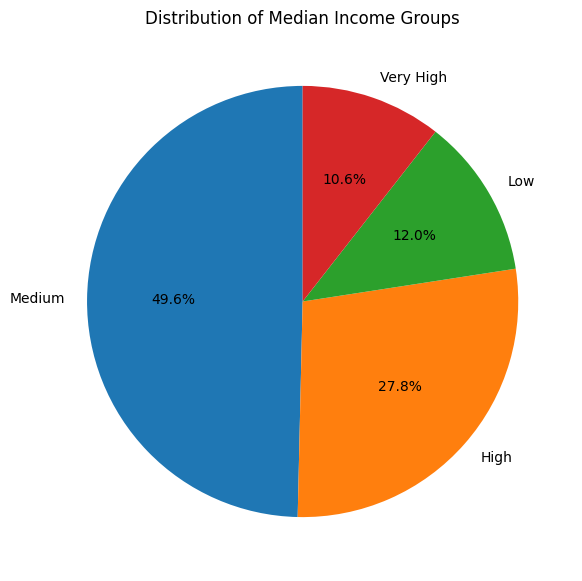

In [29]:
income_groups = pd.cut(
    df['median_income'],
    bins=[0, 2, 4, 6, np.inf],
    labels=['Low', 'Medium', 'High', 'Very High']
)

counts = income_groups.value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Distribution of Median Income Groups')
plt.show()

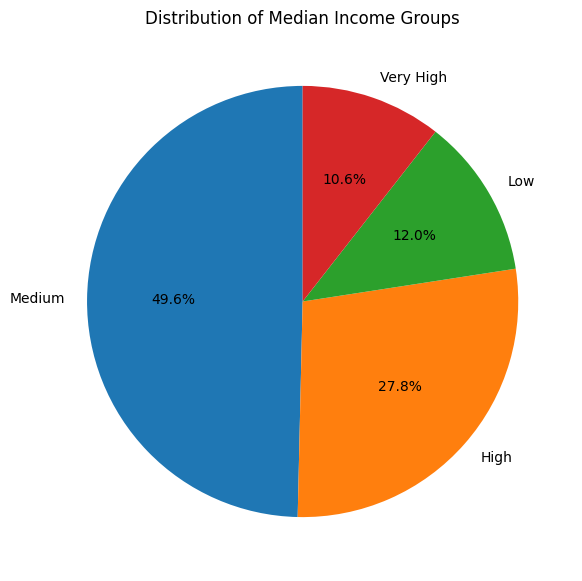

In [30]:
income_groups = pd.cut(
    df['median_income'],
    bins=[0, 2, 4, 6, np.inf],
    labels=['Low', 'Medium', 'High', 'Very High']
)

counts = income_groups.value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Distribution of Median Income Groups')
plt.show()

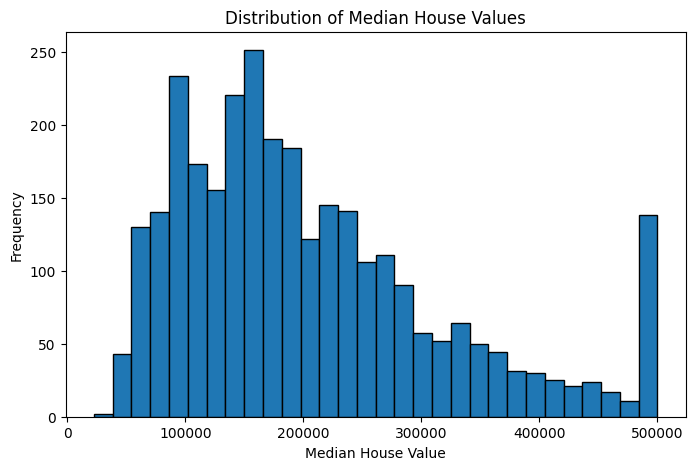

In [31]:
plt.figure(figsize=(8, 5))
plt.hist(df['median_house_value'], bins=30, edgecolor='black')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.title('Distribution of Median House Values')
plt.show()

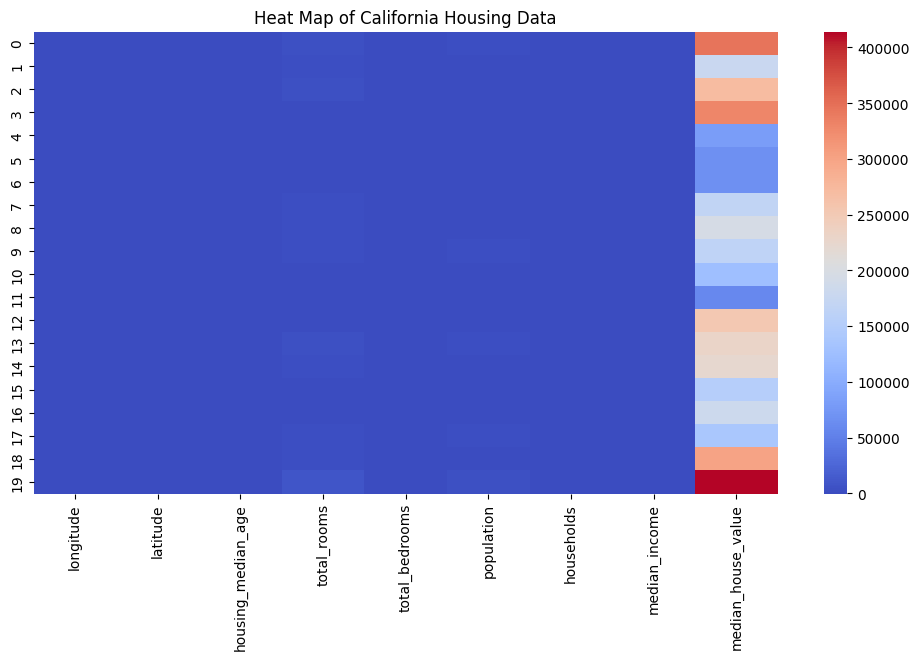

In [32]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.head(20), cmap='coolwarm')
plt.title('Heat Map of California Housing Data')
plt.show()

In [33]:
import plotly.express as px

fig = px.scatter_map(
    df,
    lat='latitude',
    lon='longitude',
    color='median_house_value',
    size='population',
    zoom=5,
    height=600,
    title='California Housing Values by Location'
)

fig.show()

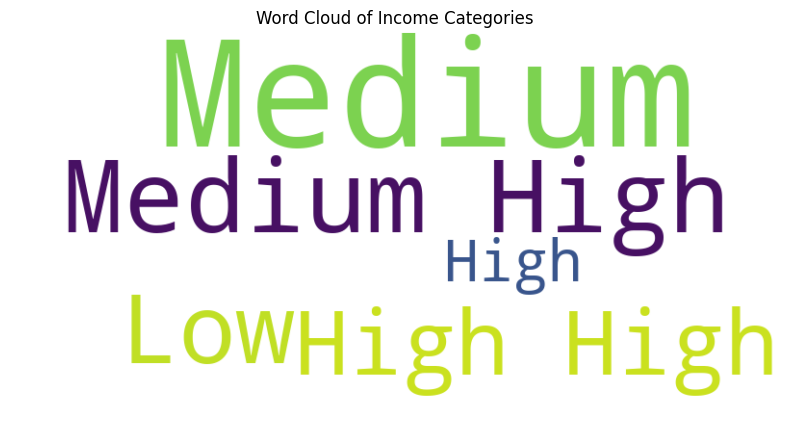

In [34]:
from wordcloud import WordCloud

income_groups = pd.cut(
    df['median_income'],
    bins=[0, 2, 4, 6, np.inf],
    labels=['Low', 'Medium', 'High', 'Very High']
)

text = ' '.join(income_groups.astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Income Categories')
plt.show()

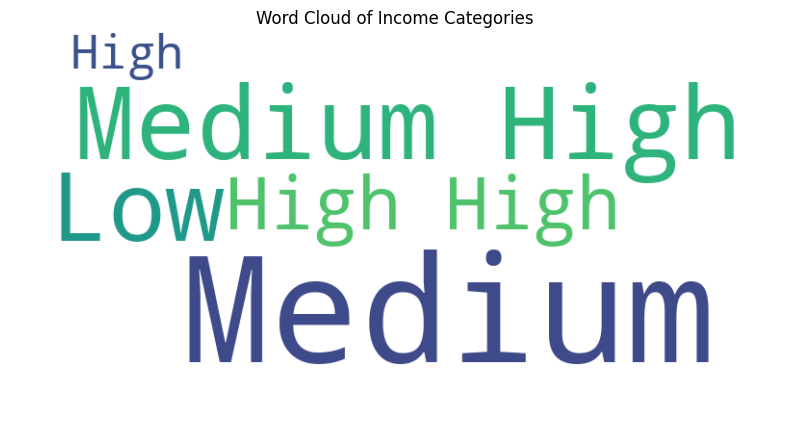

In [35]:
from wordcloud import WordCloud

income_groups = pd.cut(
    df['median_income'],
    bins=[0, 2, 4, 6, np.inf],
    labels=['Low', 'Medium', 'High', 'Very High']
)

text = ' '.join(income_groups.astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Income Categories')
plt.show()

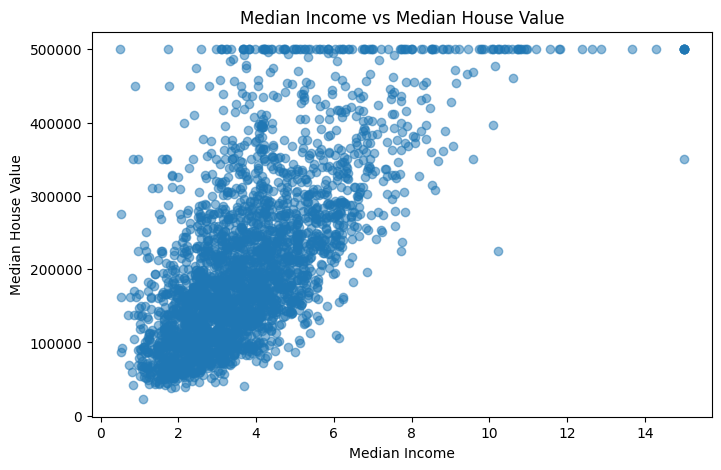

In [36]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['median_income'],
    df['median_house_value'],
    alpha=0.5
)

plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Median Income vs Median House Value')
plt.show()

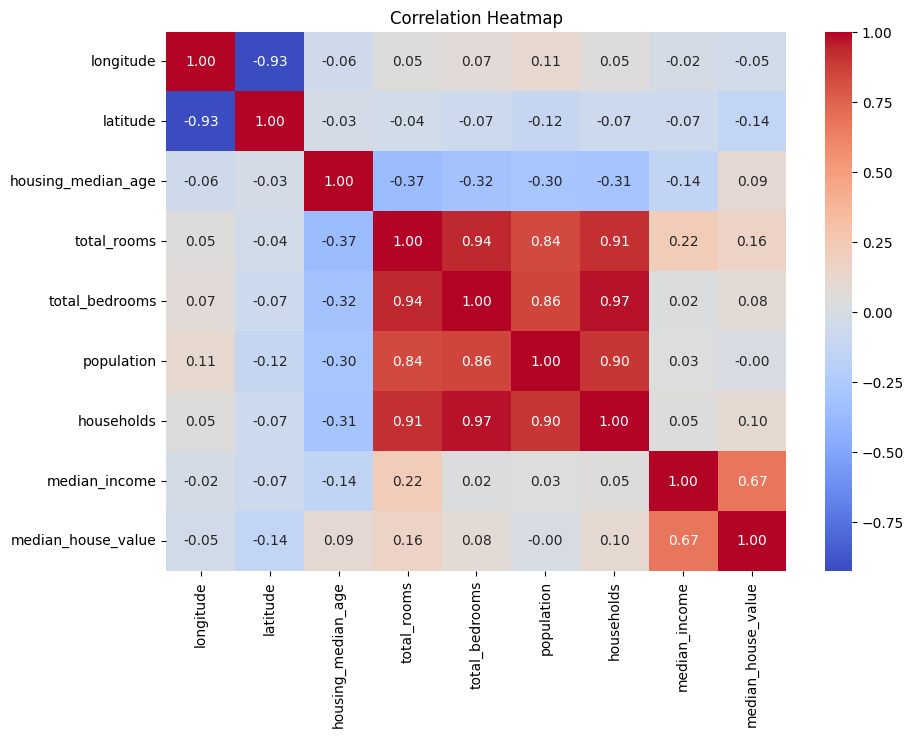

In [37]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

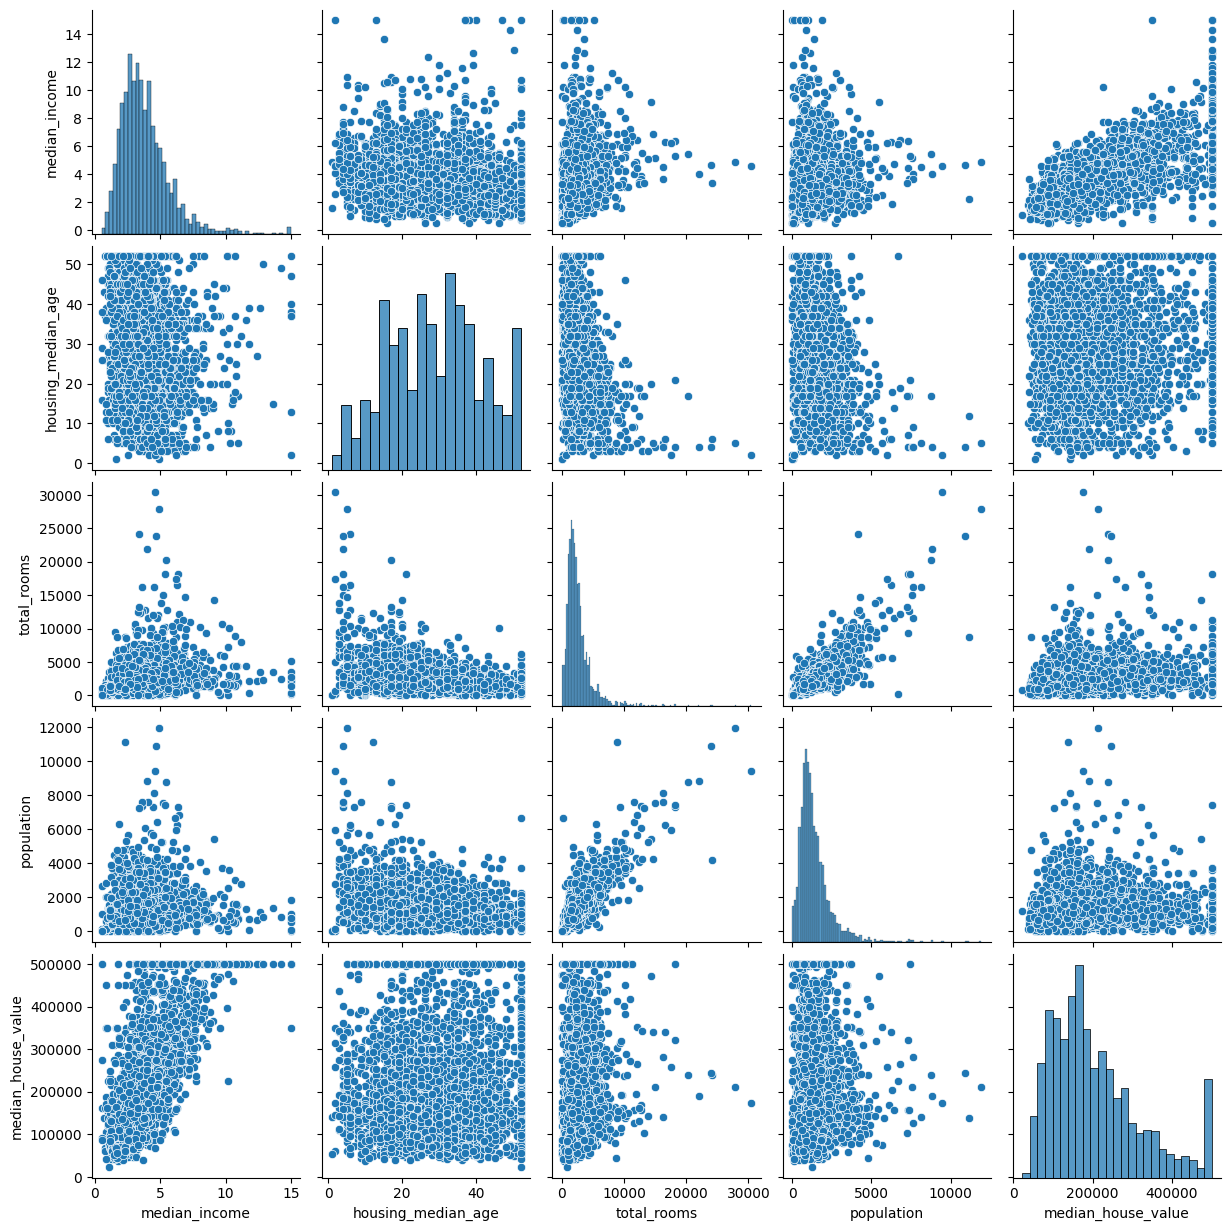

In [38]:
sns.pairplot(
    df[['median_income',
        'housing_median_age',
        'total_rooms',
        'population',
        'median_house_value']]
)

plt.show()

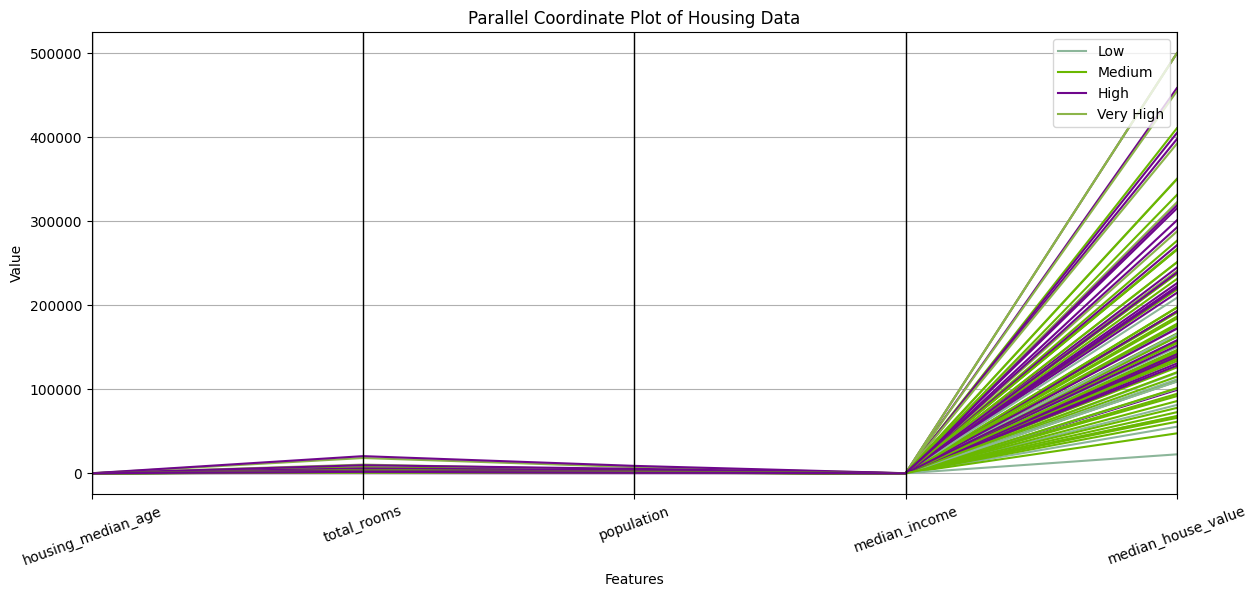

In [39]:
from pandas.plotting import parallel_coordinates

parallel_df = df[
    ['housing_median_age',
     'total_rooms',
     'population',
     'median_income',
     'median_house_value']
].copy()

parallel_df['Income_Group'] = pd.cut(
    parallel_df['median_income'],
    bins=[0, 2, 4, 6, np.inf],
    labels=['Low', 'Medium', 'High', 'Very High']
)

# Take a smaller sample so the plot remains readable
parallel_df = parallel_df.sample(100, random_state=42)

plt.figure(figsize=(14, 6))

parallel_coordinates(
    parallel_df,
    'Income_Group'
)

plt.title('Parallel Coordinate Plot of Housing Data')
plt.xlabel('Features')
plt.ylabel('Value')
plt.xticks(rotation=20)
plt.show()

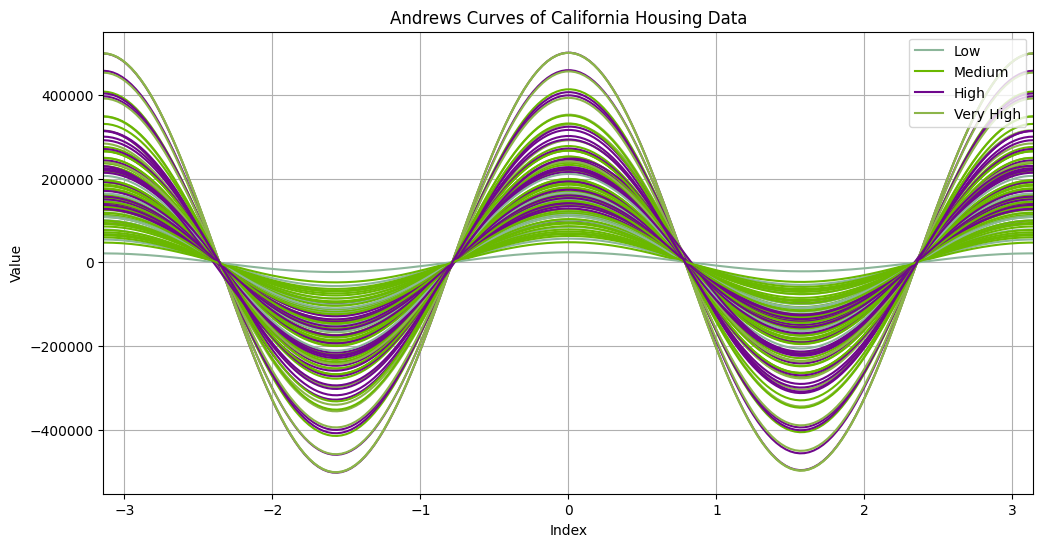

In [40]:
from pandas.plotting import andrews_curves

andrews_df = df[
    ['housing_median_age',
     'total_rooms',
     'population',
     'median_income',
     'median_house_value']
].copy()

andrews_df['Income_Group'] = pd.cut(
    andrews_df['median_income'],
    bins=[0, 2, 4, 6, np.inf],
    labels=['Low', 'Medium', 'High', 'Very High']
)

andrews_df = andrews_df.sample(100, random_state=42)

plt.figure(figsize=(12, 6))

andrews_curves(
    andrews_df,
    'Income_Group'
)

plt.title('Andrews Curves of California Housing Data')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()